# E-Commerce Customer Segmentation and Behavioral Analytics

In [19]:
import pandas as pd
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [24]:
file_path = '/content/online_retail_II.xlsx'
df = pd.read_excel(file_path)
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


# Data cleaning

In [6]:
#check null values
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


In [7]:
df = df.dropna() # delete null values
df.isnull().sum() #check

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0


In [8]:
# delete cancelled invoices
df = df[~df["Invoice"].str.contains("C", na=False)]
df = df[df["Quantity"] > 0]

In [9]:
# calculate the total for each invoice
df['TotalPrice'] = df['Quantity'] * df['Price']

In [10]:
# take last date + 1 day, this help in Recency
last_date = df['InvoiceDate'].max()+ dt.timedelta(days=1)
last_date

Timestamp('2010-12-10 20:01:00')

# RFM Feature engineering

In [11]:
# RFM
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda date: (last_date - pd.to_datetime(date).max()).days,
    'Invoice': lambda num: num.nunique(),
    'TotalPrice': lambda price: price.sum()
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']
print(rfm.head())

             Recency  Frequency  Monetary
Customer ID                              
12346.0          165         11    372.86
12347.0            3          2   1323.32
12348.0           74          1    222.16
12349.0           43          3   2671.14
12351.0           11          1    300.93


#	Models

 K-mean Clustering

In [12]:
# apply standard scaler to RFM
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# convert to dataframe
rfm_scaled_df = pd.DataFrame(
    rfm_scaled, columns=rfm.columns, index=rfm.index)
rfm_scaled_df.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,0.760643,0.801436,-0.187895
12347.0,-0.910627,-0.300464,-0.081240
12348.0,-0.178157,-0.422897,-0.204806
12349.0,-0.497968,-0.178031,0.070005
12351.0,-0.828095,-0.422897,-0.195967


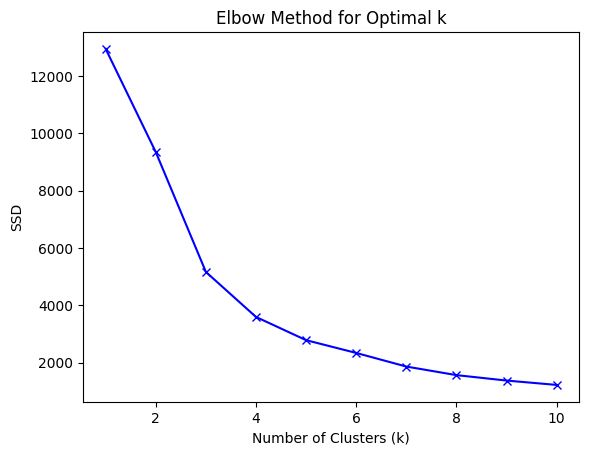

In [13]:
# apply elbow method to find the best n_clusters
ssd = [] # Sum of Squared Distances
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    ssd.append(kmeans.inertia_)

# visualize Elbow Method
plt.plot(K, ssd, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSD')
plt.title('Elbow Method for Optimal k')
plt.savefig('elbow_method.png')

In [14]:
# apply k-means clustering
# model
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(rfm_scaled)

# add cluster
rfm['Cluster'] = clusters

print(rfm.groupby('Cluster').mean())

            Recency   Frequency       Monetary
Cluster                                       
0         42.996882    4.469598    1743.129790
1        243.086749    1.658723     595.746486
2          5.600000  113.600000  215543.670000
3         15.433962   48.547170   29040.181566


In [22]:
# number of customers in each cluster
rfm['Cluster'].value_counts()

,count
Cluster,
0,3207
1,1049
3,53
2,5


Segment Characterization:

Cluster 2 (Champions): These are the VIP customers. With a very high frequency (114 orders) and massive spending (215k), they are the most valuable. Their low recency (5 days) shows they are highly active.

Cluster 3 (Loyalists): High-value customers who shop frequently (48 orders) and spend generously (29k). They are consistent and reliable contributors to revenue.

Cluster 0 (Potential Loyalists): Moderate shoppers who visit every 1-2 months. They have a good foundation but require incentives to increase their frequency.

Cluster 1 (At-Risk / Hibernating): Customers who haven't purchased in over 8 months (243 days). Their low engagement suggests they are likely to churn if no action is taken.

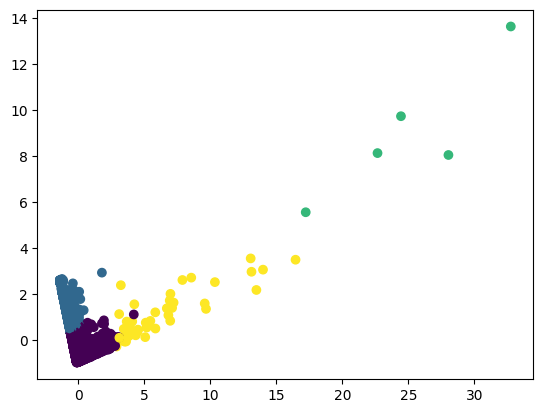

In [20]:
# apply PCA to visualize clusters
pca = PCA(n_components=2)
pca_data = pca.fit_transform(rfm_scaled)

plt.scatter(pca_data[:,0], pca_data[:,1], c=clusters)

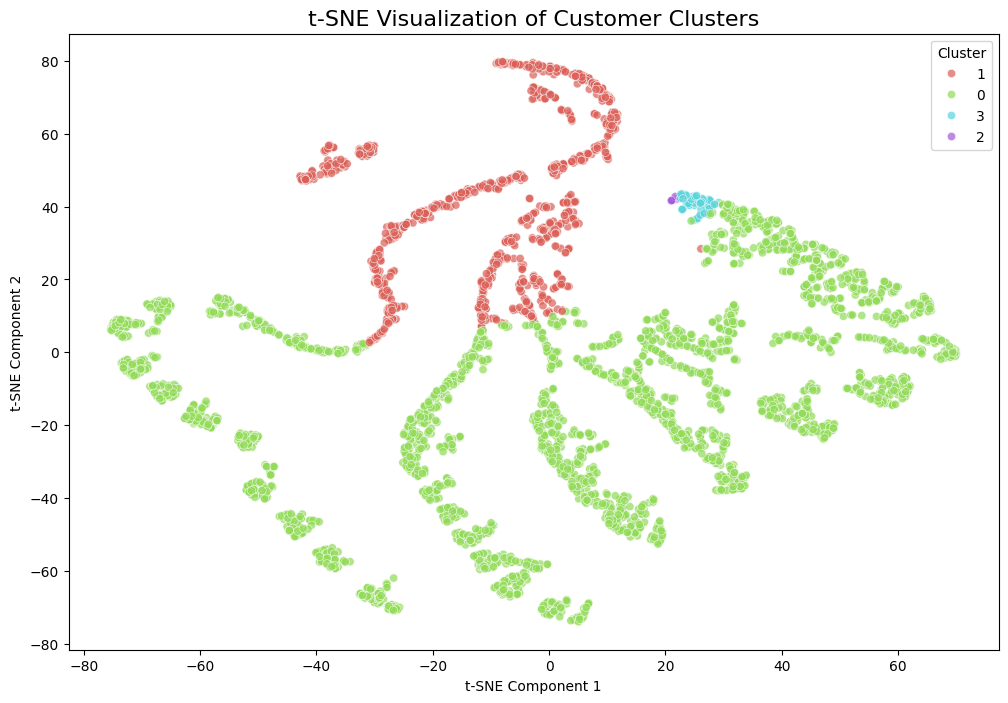

In [15]:
# apply t-SNE to visualize clusters
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(rfm_scaled)

# new DataFrame
df_tsne = pd.DataFrame(tsne_results, columns=['tsne_1', 'tsne_2'])
df_tsne['Cluster'] = clusters.astype(str) # for colors

# plot using Seaborn
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x="tsne_1", y="tsne_2",
    hue="Cluster",
    palette=sns.color_palette("hls", 4), # 4 clustes
    data=df_tsne,
    legend="full",
    alpha=0.7
)

plt.title('t-SNE Visualization of Customer Clusters', fontsize=16)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.savefig('tsne_clusters.png')
plt.show()

In [16]:
# evalute the model
score = silhouette_score(rfm_scaled, clusters)
print(f'Silhouette Score: {score:.3f}')

Silhouette Score: 0.610
